# Day 2 종합실습 — Adult 탐색적 데이터 분석(EDA) 과정

**판교 8반 정승원**

이 노트북은 Adult Census Income 데이터의 EDA 코드와 해석 과정을 한 흐름으로 재구성한다.

핵심 순서는 **분석 범위 설정 → 구조·품질 확인 → 단변량 요약 → 타깃별 비교 → 변수 간 관계 → 정적·인터랙티브 시각화 → 관찰 결과와 한계 정리**다. EDA는 패턴을 발견하고 후속 가설을 만드는 단계이며 인과관계나 통계적 유의성을 확정하는 단계가 아니다.


## 0. 실행 환경과 참고 파일

이 노트북은 저장소 규칙(`AGENTS.md` 1절)에 따라 **독립 실행형**이다. `src/`를 import하지 않고 필요한 상수·로딩·집계 코드를 노트북 안에 직접 담는다. 노트북에서 검증이 끝난 로직을 `src/eda.py`, `src/viz.py`로 옮길 때 예외 처리·타입 힌트·값 객체·테스트를 붙인다.

- 입력: `data/adult.data` (EDA 대상), `data/adult.test` (최종 평가용 잠금 데이터)
- 출력: `outputs/eda/figures/*.png`, `outputs/eda/interactive/*.html`, `outputs/eda/eda.json`
- 원본이 없으면 UCI에서 자동으로 내려받아 `data/`에 캐시한다.


In [1]:
from __future__ import annotations

import json
import urllib.error
import urllib.request
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns

# 프로젝트 루트 탐색 — notebooks/ 안에서 실행하든 루트에서 실행하든 같은 경로를 쓴다.
ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    candidates = [p for p in [ROOT, *ROOT.parents] if (p / "data").exists()]
    if not candidates:
        raise FileNotFoundError("data/ 폴더가 있는 프로젝트에서 실행하세요.")
    ROOT = candidates[0]

DATA_RAW = ROOT / "data"
EDA_OUT = ROOT / "outputs" / "eda"
FIG_DIR = EDA_OUT / "figures"
HTML_DIR = EDA_OUT / "interactive"
for directory in (FIG_DIR, HTML_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# 원본에 헤더가 없으므로 UCI 문서의 공식 컬럼명을 직접 부여한다.
COLS = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income",
]
NUM_COLS = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
CAT_COLS = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
]
TARGET = "income"
BASE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/"

# 한글 축 라벨이 두부(□)로 깨지지 않도록 시스템에 있는 한글 폰트를 우선 지정한다.
_installed = {f.name for f in fm.fontManager.ttflist}
for _candidate in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _candidate in _installed:
        plt.rcParams["font.family"] = _candidate
        break
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트에는 유니코드 마이너스 글리프가 없다.

sns.set_theme(style="whitegrid", palette="colorblind", font=plt.rcParams["font.family"][0])
# notebook_connected: plotly.js를 노트북 파일에 3MB씩 굽지 않고 CDN에서 불러온다.
pio.renderers.default = "notebook_connected"

print("프로젝트 루트:", ROOT)
print("matplotlib 한글 폰트:", plt.rcParams["font.family"][0])


프로젝트 루트: /Users/donghyeon/skala-workspace/week4/team-analysis
matplotlib 한글 폰트: AppleGothic


In [2]:
# --------------------------------------------------
# 함수명 : ensure_raw
# 목적   : 원본 파일이 캐시에 없으면 UCI에서 내려받아 저장
# 매개변수: name(str) - 파일명 ('adult.data' | 'adult.test')
# 반환값 : Path - 캐시된 원본 파일 경로
# --------------------------------------------------
def ensure_raw(name: str) -> Path:
    path = DATA_RAW / name
    if path.exists() and path.stat().st_size > 0:
        return path
    try:
        with urllib.request.urlopen(BASE_URL + name, timeout=60) as response:
            payload = response.read()
    except (urllib.error.URLError, TimeoutError) as exc:
        raise RuntimeError(f"{name} 다운로드 실패 — 네트워크를 확인하세요: {exc}") from exc
    path.write_bytes(payload)
    return path


# --------------------------------------------------
# 함수명 : load_adult
# 목적   : Adult 원본을 프로젝트 규칙대로 파싱해 DataFrame으로 반환
# 매개변수: name(str) - 파일명, is_test(bool) - adult.test 여부
# 반환값 : pd.DataFrame - 15개 컬럼의 원본 데이터 (행 삭제·대체 없음)
# --------------------------------------------------
def load_adult(name: str, is_test: bool = False) -> pd.DataFrame:
    path = ensure_raw(name)
    try:
        df = pd.read_csv(
            path,
            header=None,
            names=COLS,
            skipinitialspace=True,   # 쉼표 뒤 선행 공백 제거
            na_values=["?", " ?"],   # 결측 토큰을 실제 NaN으로
            skiprows=1 if is_test else 0,  # adult.test 첫 줄은 메타데이터
        )
    except (OSError, pd.errors.ParserError) as exc:
        raise RuntimeError(f"{path} 파싱 실패: {exc}") from exc
    if is_test:
        # test 라벨에는 마침표가 붙어 있다: '>50K.' → '>50K'
        df[TARGET] = df[TARGET].str.rstrip(".")
    return df


train = load_adult("adult.data")
test_locked = load_adult("adult.test", is_test=True)

assert train.shape == (32561, 15)
assert test_locked.shape == (16281, 15)
assert set(train[TARGET]) == set(test_locked[TARGET]) == {"<=50K", ">50K"}
print(f"EDA 대상: adult.data {train.shape[0]:,}행 × {train.shape[1]}열")
print(f"잠금 유지: adult.test {test_locked.shape[0]:,}행 — 최종 평가 전까지 EDA에 미사용")
train.head()


EDA 대상: adult.data 32,561행 × 15열
잠금 유지: adult.test 16,281행 — 최종 평가 전까지 EDA에 미사용


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1. EDA 범위와 원칙

이 프로젝트의 EDA에는 `adult.data` 학습 데이터만 사용한다. `adult.test`는 최종 모델 평가용 잠금 데이터이므로 EDA 과정에서 분포를 보고 의사결정을 조정하지 않는다.

또한 품질 진단 결과에 따라 다음 정책을 유지한다.

- `?`는 실제 결측값 `NaN`으로 파싱
- 결측행은 EDA 전체에서 일괄 삭제하지 않음
- 완전 동일 중복행은 개인 식별자가 없어 유지
- 통계적 극단값은 오류 근거가 없어 유지
- 각 집계·차트는 필요한 변수의 결측만 연산에서 제외
- EDA 관찰은 연관성·경향으로 표현하고 인과관계로 해석하지 않음


## 2. 데이터 구조와 품질 확인

EDA를 시작하기 전에 행·열 수, 자료형, 결측, 중복, 범주 수를 확인한다. 이 단계는 숫자처럼 보여야 하는 열이 문자열로 읽히거나, 결측 토큰이 일반 범주로 남아 있는 파싱 오류를 먼저 잡기 위한 과정이다.


In [3]:
structure = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "non_null": train.notna().sum(),
    "missing": train.isna().sum(),
    "missing_pct": (train.isna().mean() * 100).round(2),
    "n_unique_observed": train.nunique(dropna=True),
})
structure


,dtype,non_null,missing,missing_pct,n_unique_observed
age,int64,32561,0,0.00,73
workclass,str,30725,1836,5.64,8
fnlwgt,int64,32561,0,0.00,21648
education,str,32561,0,0.00,16
education-num,int64,32561,0,0.00,16
marital-status,str,32561,0,0.00,7
occupation,str,30718,1843,5.66,14
relationship,str,32561,0,0.00,6
race,str,32561,0,0.00,5
sex,str,32561,0,0.00,2


In [4]:
quality_overview = pd.Series({
    "rows": len(train),
    "columns": train.shape[1],
    "rows_with_any_missing": int(train.isna().any(axis=1).sum()),
    "missing_cells_total": int(train.isna().sum().sum()),
    "exact_duplicate_rows": int(train.duplicated().sum()),
    "capital_gain_99999": int((train["capital-gain"] == 99999).sum()),
    "hours_per_week_99": int((train["hours-per-week"] == 99).sum()),
    "age_90": int((train["age"] >= 90).sum()),
}, name="value")
quality_overview


rows                     32561
columns                     15
rows_with_any_missing     2399
missing_cells_total       4262
exact_duplicate_rows        24
capital_gain_99999         159
hours_per_week_99           85
age_90                      43
Name: value, dtype: int64

### 품질 확인 결과

- 결측은 `workclass`, `occupation`, `native-country`에만 존재한다.
- 전체 32,561행 중 결측 보유 행은 2,399개다.
- 완전 동일 행은 24개지만 식별자가 없어 실제 중복 응답인지 판정할 수 없다.
- `capital-gain=99999`, `hours-per-week=99`, `age=90`은 극단값이지만 오류라는 근거가 없다.

따라서 원본 행을 보존한 상태에서 EDA를 진행한다. 결측이 포함된 범주형 집계는 `NaN`도 하나의 상태처럼 보이도록 `dropna=False`를 사용한다.


## 3. 타깃 분포와 클래스 불균형

예측 대상 `income`은 `<=50K`와 `>50K` 두 범주다. 고소득 비율을 먼저 확인하면 이후 모델 평가에서 accuracy만 사용할 수 없는 이유를 알 수 있다.


In [5]:
income_counts = train[TARGET].value_counts().rename("count").to_frame()
income_counts["pct"] = (income_counts["count"] / len(train) * 100).round(2)
high_income_rate = (train[TARGET] == ">50K").mean()
assert round(high_income_rate, 4) == 0.2408
income_counts


,count,pct
income,,
<=50K,24720,75.92
>50K,7841,24.08


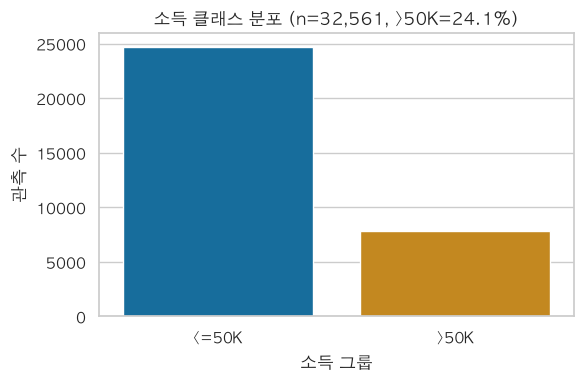

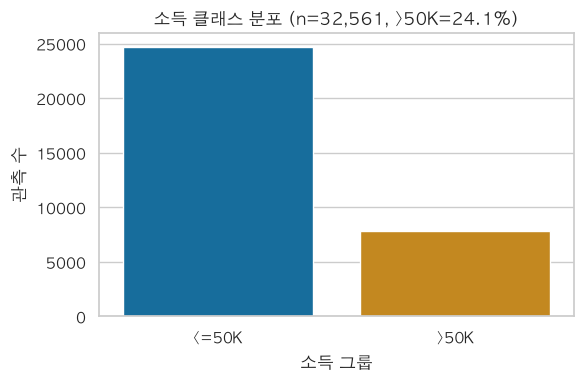

In [6]:
fig_target, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train, x=TARGET, hue=TARGET, legend=False, ax=ax)
ax.set_title(f"소득 클래스 분포 (n={len(train):,}, >50K={high_income_rate:.1%})")
ax.set_xlabel("소득 그룹")
ax.set_ylabel("관측 수")
fig_target.tight_layout()
fig_target.savefig(FIG_DIR / "00_income_distribution.png", dpi=120)
fig_target


고소득 비율은 약 24.1%로 클래스가 불균형하다. 따라서 모델 단계에서는 accuracy와 함께 F1, balanced accuracy, ROC-AUC를 사용한다.


## 4. 수치형 변수 단변량 분석

평균·표준편차뿐 아니라 중앙값과 사분위수를 같이 확인한다. `capital-gain`, `capital-loss`처럼 0이 많은 변수에서는 평균이 대표값 역할을 잘 하지 못하기 때문이다.


In [7]:
numeric_summary = train[NUM_COLS].describe().T
numeric_summary["skew"] = train[NUM_COLS].skew()
numeric_summary["zero_pct"] = (train[NUM_COLS].eq(0).mean() * 100).round(2)
numeric_summary.round(3)


,count,mean,std,min,25%,50%,75%,max,skew,zero_pct
age,32561.0,38.582,13.640,17.0,28.0,37.0,48.0,90.0,0.559,0.00
fnlwgt,32561.0,189778.367,105549.978,12285.0,117827.0,178356.0,237051.0,1484705.0,1.447,0.00
education-num,32561.0,10.081,2.573,1.0,9.0,10.0,12.0,16.0,-0.312,0.00
capital-gain,32561.0,1077.649,7385.292,0.0,0.0,0.0,0.0,99999.0,11.954,91.67
capital-loss,32561.0,87.304,402.960,0.0,0.0,0.0,0.0,4356.0,4.595,95.33
hours-per-week,32561.0,40.437,12.347,1.0,40.0,40.0,45.0,99.0,0.228,0.00


### 수치형 요약 해석

- `age`: 17~90세, 중앙값 37세.
- `hours-per-week`: 중앙값 40시간이고 40시간에 큰 집중이 있다.
- `capital-gain/loss`: 대부분 0이며 오른쪽 꼬리가 매우 길다. 평균보다 분위수·0 비율을 같이 봐야 한다.
- `fnlwgt`: 개인 특성이 아니라 Census 표본 가중치다. EDA 기술통계에는 포함하지만 예측 특징에서는 제외한다.


## 5. 범주형 변수 단변량 분석

각 범주의 빈도와 고유 범주 수를 확인한다. 희소 범주가 많으면 비율 비교가 불안정하거나 원핫 인코딩 차원이 커질 수 있다.


In [8]:
categorical_overview = pd.DataFrame([
    {
        "column": column,
        "observed_categories": train[column].nunique(dropna=True),
        "mode_including_missing": str(train[column].value_counts(dropna=False).index[0]),
        "mode_count": int(train[column].value_counts(dropna=False).iloc[0]),
        "rare_categories_under_50": int((train[column].value_counts(dropna=False) < 50).sum()),
    }
    for column in [*CAT_COLS, TARGET]
])
categorical_overview


,column,observed_categories,mode_including_missing,mode_count,rare_categories_under_50
0,workclass,8,Private,22696,2
1,education,16,HS-grad,10501,0
2,marital-status,7,Married-civ-spouse,14976,1
3,occupation,14,Prof-specialty,4140,1
4,relationship,6,Husband,13193,0
5,race,5,White,27816,0
6,sex,2,Male,21790,0
7,native-country,41,United-States,29170,20
8,income,2,<=50K,24720,0


In [9]:
top_categories = {
    column: train[column].value_counts(dropna=False).head(8)
    for column in [*CAT_COLS, TARGET]
}
pd.DataFrame(top_categories).fillna(0).astype(int)


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
10th,0,933,0,0,0,0,0,0,0
11th,0,1175,0,0,0,0,0,0,0
<=50K,0,0,0,0,0,0,0,0,24720
>50K,0,0,0,0,0,0,0,0,7841
Adm-clerical,0,0,0,3770,0,0,0,0,0
Amer-Indian-Eskimo,0,0,0,0,0,311,0,0,0
Asian-Pac-Islander,0,0,0,0,0,1039,0,0,0
Assoc-acdm,0,1067,0,0,0,0,0,0,0
Assoc-voc,0,1382,0,0,0,0,0,0,0
Bachelors,0,5355,0,0,0,0,0,0,0


## 6. 소득 그룹별 수치 비교

단변량 분포 다음에는 타깃 그룹별 중심과 분산을 비교한다. 여기서 보이는 차이는 후속 통계 검정의 후보이며, 그 자체로 유의성이나 인과성을 뜻하지 않는다.


In [10]:
group_numeric = train.groupby(TARGET)[NUM_COLS].agg(["count", "mean", "median", "std"])
group_numeric.round(3)


age                        fnlwgt                                    \
        count    mean median     std  count        mean    median         std   
income                                                                          
<=50K   24720  36.784   34.0  14.020  24720  190340.865  179465.0  106482.271   
>50K     7841  44.250   44.0  10.519   7841  188005.000  176101.0  102541.775   

       education-num          ... capital-gain            capital-loss  \
               count    mean  ...       median        std        count   
income                        ...                                        
<=50K          24720   9.595  ...          0.0    963.139        24720   
>50K            7841  11.612  ...          0.0  14570.379         7841   

                                hours-per-week                         
           mean median      std          count    mean median     std  
income                                                                 
<=50K    53.143    0.0  310.756          24720  38.840   40.0  12.319  
>50K    195.002    0.0  595.488           7841  45.473   40.0  11.013  

[2 rows x 24 columns]

관찰상 `>50K` 그룹은 나이·교육연수·주당 근로시간의 중심이 더 높다. 이는 관측 연관성이며 경력, 직종, 혼인 상태 등 다른 변수의 영향을 통제한 결과가 아니다.


## 7. 정적 시각화 1 — 소득 그룹별 주당 근로시간

H1에서 검정할 `hours-per-week`의 전체 형태와 그룹 간 이동을 먼저 확인한다. 그룹별 표본 수가 다르므로 `density`와 `common_norm=False`를 사용해 분포 형태를 비교한다.


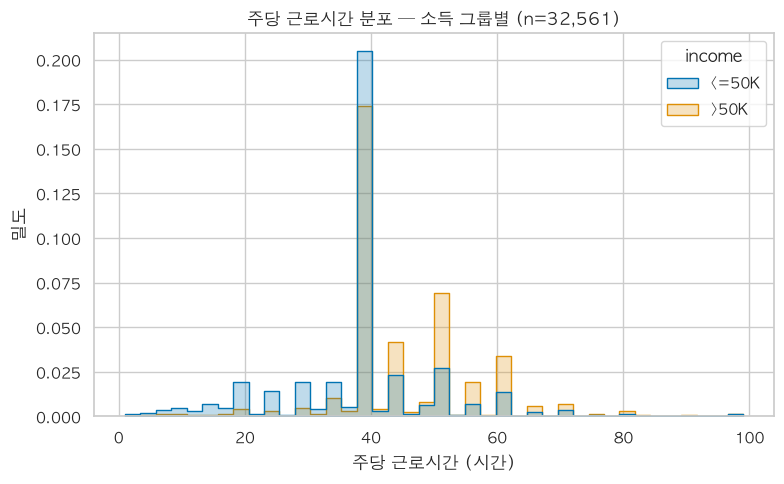

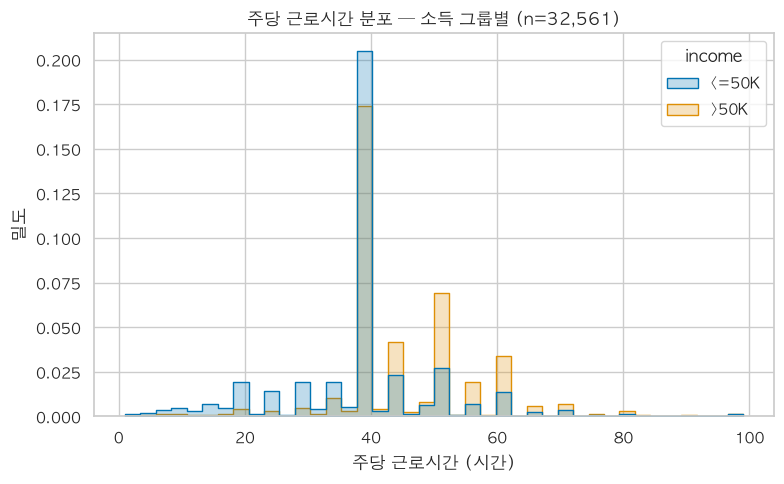

In [11]:
fig_hours, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=train, x="hours-per-week", hue=TARGET, bins=40,
    stat="density", common_norm=False, element="step", ax=ax,
)
ax.set_title(f"주당 근로시간 분포 — 소득 그룹별 (n={len(train):,})")
ax.set_xlabel("주당 근로시간 (시간)")
ax.set_ylabel("밀도")
fig_hours.tight_layout()
fig_hours.savefig(FIG_DIR / "01_hours_by_income_hist.png", dpi=120)
fig_hours


두 그룹 모두 40시간에 강한 스파이크가 있고 `>50K` 그룹이 오른쪽으로 이동해 있다. 이후 Welch t-test에서 평균차·신뢰구간·효과크기를 확인한다.

저장 위치: `outputs/eda/figures/01_hours_by_income_hist.png`


## 8. 정적 시각화 2 — 소득 그룹별 연령

박스플롯으로 중앙값, 사분위 범위, 꼬리와 극단 관측을 동시에 비교한다.


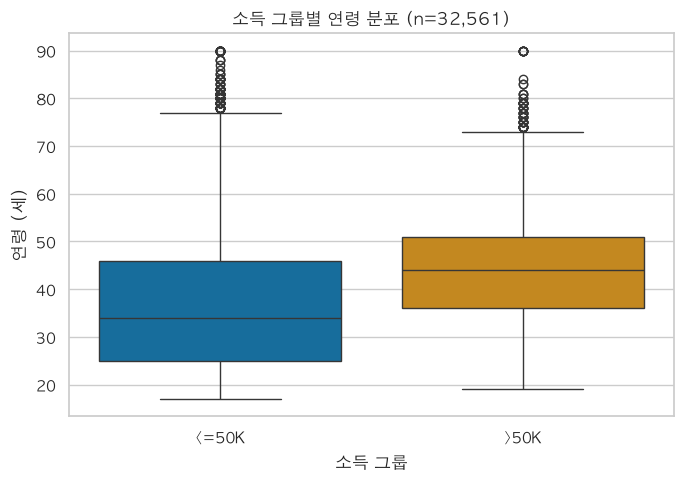

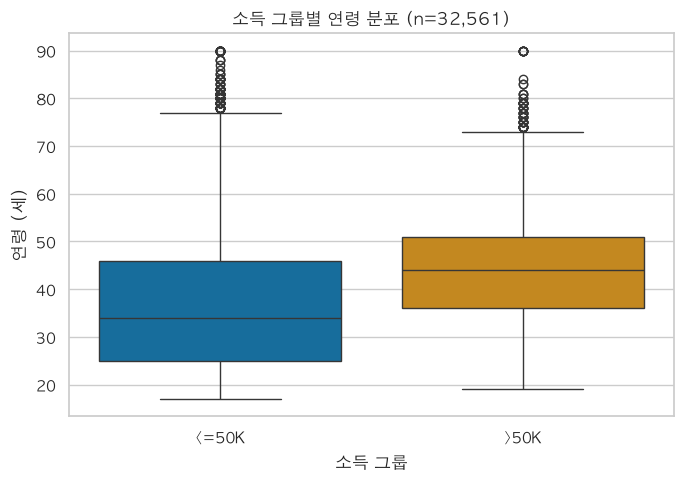

In [12]:
fig_age, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=train, x=TARGET, y="age", hue=TARGET, legend=False, ax=ax)
ax.set_title(f"소득 그룹별 연령 분포 (n={len(train):,})")
ax.set_xlabel("소득 그룹")
ax.set_ylabel("연령 (세)")
fig_age.tight_layout()
fig_age.savefig(FIG_DIR / "02_age_by_income_box.png", dpi=120)
fig_age


고소득 그룹의 연령 중앙값이 더 높다. 이것을 '나이가 소득을 높인다'거나 '경력 효과가 증명됐다'고 해석할 수는 없다. 연령은 교육·직업·혼인 상태 등과 함께 변한다.

저장 위치: `outputs/eda/figures/02_age_by_income_box.png`


## 9. 정적 시각화 3 — 수치형 Pearson 상관행렬

수치형 변수 사이의 선형 관계를 탐색한다. Pearson 상관은 비선형 관계나 범주형 변수와의 관계를 포착하지 못하며, p-value가 아니라 관계의 방향·크기를 보는 EDA 요약이다.


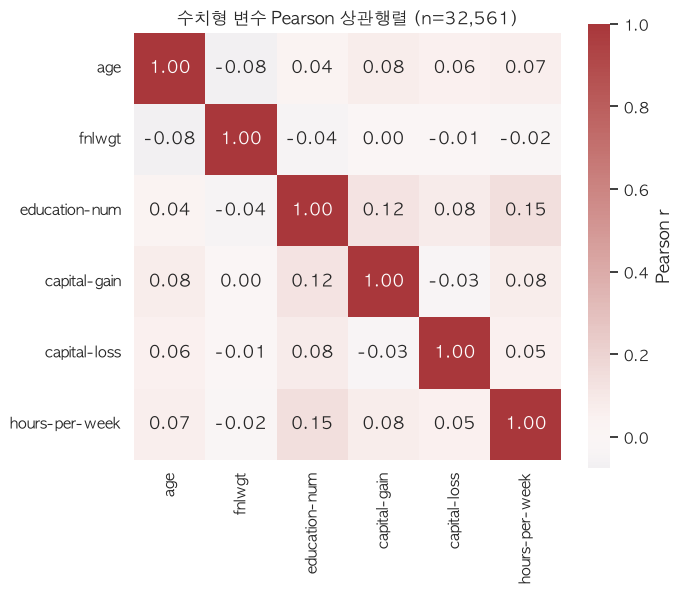

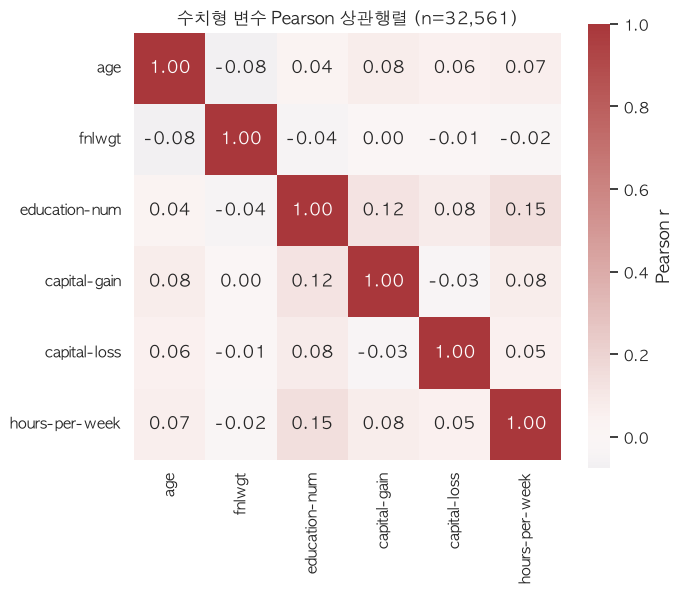

In [13]:
corr = train[NUM_COLS].corr()
fig_corr, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
    cbar_kws={"label": "Pearson r"}, ax=ax,
)
ax.set_title(f"수치형 변수 Pearson 상관행렬 (n={len(train):,})")
fig_corr.tight_layout()
fig_corr.savefig(FIG_DIR / "03_corr_heatmap.png", dpi=120)
fig_corr


수치형 변수 간 선형 상관은 전반적으로 약하다. `fnlwgt`도 다른 변수와 거의 무상관이지만, 이것만이 모델에서 제외한 이유는 아니다. 본래 표본 가중치라는 변수 의미 때문에 개인 예측 특징에서 제외한다.

저장 위치: `outputs/eda/figures/03_corr_heatmap.png`


## 10. 정적 시각화 4 — 교육수준별 고소득 비율

교육 범주를 문자순이 아니라 대응하는 `education-num` 순서로 정렬한 뒤 고소득 비율을 계산한다. 범주별 분모도 함께 확인해야 적은 표본의 높은 비율을 과대해석하지 않는다.


In [14]:
education_order = (
    train.groupby("education")["education-num"].first().sort_values().index.tolist()
)
education_income = (
    train.assign(high=(train[TARGET] == ">50K").astype(float))
    .groupby("education")
    .agg(
        n=("high", "size"),
        high_income_rate=("high", "mean"),
        education_num=("education-num", "first"),
    )
    .reindex(education_order)
)
education_income


,n,high_income_rate,education_num
education,,,
Preschool,51,0.000000,1
1st-4th,168,0.035714,2
5th-6th,333,0.048048,3
7th-8th,646,0.061920,4
9th,514,0.052529,5
10th,933,0.066452,6
11th,1175,0.051064,7
12th,433,0.076212,8
HS-grad,10501,0.159509,9


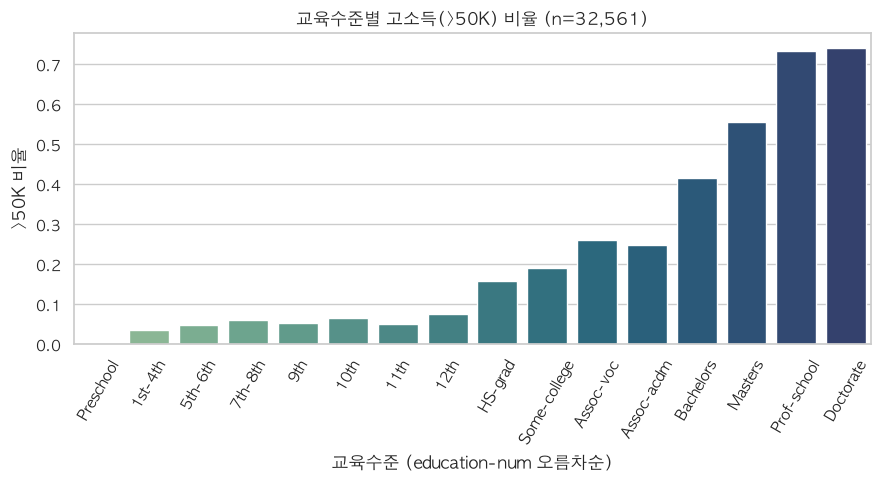

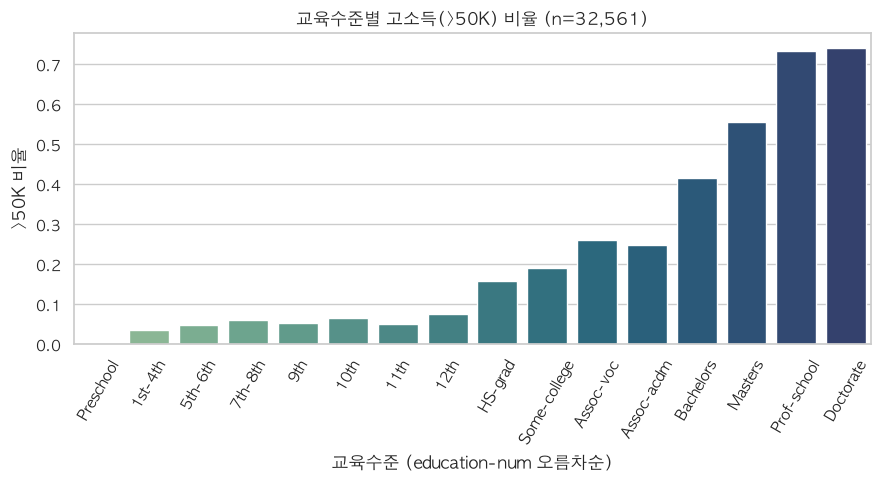

In [15]:
fig_education, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x=education_income.index, y=education_income["high_income_rate"],
    hue=education_income.index, legend=False, palette="crest", ax=ax,
)
ax.set_title(f"교육수준별 고소득(>50K) 비율 (n={len(train):,})")
ax.set_xlabel("교육수준 (education-num 오름차순)")
ax.set_ylabel(">50K 비율")
ax.tick_params(axis="x", rotation=60)
fig_education.tight_layout()
fig_education.savefig(FIG_DIR / "04_income_rate_by_education.png", dpi=120)
fig_education


교육수준이 높을수록 고소득 비율이 전반적으로 증가하지만 모든 인접 단계에서 엄밀하게 단조 증가하지는 않는다. 이는 다른 변수들을 통제하지 않은 범주별 원비율이다.

저장 위치: `outputs/eda/figures/04_income_rate_by_education.png`


## 11. 인터랙티브 시각화 1 — 직업군별 근로시간과 소득

직업 결측 1,843행은 이 차트에서만 제외한다. 직업군을 주당 근로시간 중앙값 순으로 정렬하고 소득 그룹을 색으로 나눠 직업 내부와 직업 간 분포를 동시에 탐색한다.


In [16]:
occupation_df = train.dropna(subset=["occupation"]).copy()
occupation_order = (
    occupation_df.groupby("occupation")["hours-per-week"].median().sort_values().index.tolist()
)
fig_occupation = px.box(
    occupation_df, x="occupation", y="hours-per-week", color=TARGET,
    category_orders={"occupation": occupation_order},
    title=f"직업군별 주당 근로시간 분포 — 소득 그룹 비교 (n={len(occupation_df):,})",
    labels={
        "occupation": "직업군",
        "hours-per-week": "주당 근로시간 (시간)",
        "income": "소득 그룹",
    },
)
fig_occupation.update_layout(xaxis_tickangle=-45, legend_title_text="소득 그룹")
assert len(occupation_df) == 30718
fig_occupation.write_html(HTML_DIR / "occupation_hours_box.html", include_plotlyjs="cdn")
fig_occupation


직업군별 분포 차이와 같은 직업 안의 소득 그룹 차이가 함께 보인다. 직업·근로시간·소득의 관계를 인과적으로 분리한 결과는 아니다.

오프라인 HTML: `outputs/eda/interactive/occupation_hours_box.html`


## 12. 인터랙티브 시각화 2 — 연령대 × 교육수준 고소득 비율

연령을 6개 구간으로 나누고 교육수준별 고소득 비율을 피벗한다. 색이 진한 셀은 비율이 높다는 뜻이며, 상호작용의 통계적 존재를 검정한 결과는 아니다. 셀 표본 수가 작으면 비율이 불안정할 수 있어 count 피벗도 함께 확인한다.


In [17]:
age_education = train.copy()
age_education["age_group"] = pd.cut(
    age_education["age"], bins=[16, 25, 35, 45, 55, 65, 100],
    labels=["17-25", "26-35", "36-45", "46-55", "56-65", "66+"],
)
age_education["high"] = (age_education[TARGET] == ">50K").astype(float)
rate_pivot = age_education.pivot_table(
    index="education", columns="age_group", values="high", aggfunc="mean", observed=True
).reindex(education_order)
count_pivot = age_education.pivot_table(
    index="education", columns="age_group", values="high", aggfunc="size", observed=True
).reindex(education_order)

fig_age_education = px.imshow(
    rate_pivot.round(3),
    title=f"연령대 × 교육수준별 고소득(>50K) 비율 (n={len(age_education):,})",
    labels={"x": "연령대", "y": "교육수준", "color": ">50K 비율"},
    color_continuous_scale="Blues", aspect="auto", text_auto=".2f",
)
fig_age_education.write_html(
    HTML_DIR / "age_education_income_heatmap.html", include_plotlyjs="cdn"
)
print("셀별 표본 수 — 작은 셀 해석 주의")
print(count_pivot.to_string())
fig_age_education


셀별 표본 수 — 작은 셀 해석 주의
age_group     17-25  26-35  36-45  46-55  56-65  66+
education                                           
Preschool         9      9     10     14      5    4
1st-4th          20     28     34     33     35   18
5th-6th          51     70     68     67     49   28
7th-8th          66    106     88    137    156   93
9th             106    111     96     83     81   37
10th            290    193    137    138    125   50
11th            529    229    157    131     91   38
12th            195     90     65     44     33    6
HS-grad        1878   2907   2503   1831   1013  369
Some-college   2202   1732   1639   1035    499  184
Assoc-voc       167    449    416    229     86   35
Assoc-acdm      166    338    322    170     55   16
Bachelors       681   1699   1555    883    392  145
Masters          47    356    595    482    180   63
Prof-school       3    126    209    133     69   36
Doctorate         1     71    115    128     62   36


고연령·고교육 구간에서 고소득 비율이 높은 패턴이 보이지만, 셀별 표본 수와 다른 공변량을 고려하지 않은 기술적 요약이다.

오프라인 HTML: `outputs/eda/interactive/age_education_income_heatmap.html`


## 13. 결과 수치 저장과 산출물 자체 검증

노트북에서 계산한 핵심 수치를 `outputs/eda/eda.json`으로 저장한다. 이 값들은 이후 `src/eda.py`를 구현할 때 회귀 비교 기준(golden values)으로 쓸 수 있다. 마지막으로 정적 차트 4종과 인터랙티브 HTML 2종이 실제로 생성됐는지 확인한다.


In [18]:
eda_metrics = {
    "n_rows": int(len(train)),
    "n_cols": int(train.shape[1]),
    "high_income_rate": round(float(high_income_rate), 4),
    "rows_with_any_missing": int(train.isna().any(axis=1).sum()),
    "exact_duplicate_rows": int(train.duplicated().sum()),
    "numeric_describe": {
        column: {stat: round(float(value), 3) for stat, value in summary.items()}
        for column, summary in train[NUM_COLS].describe().to_dict().items()
    },
    "static_charts": [
        "figures/00_income_distribution.png",
        "figures/01_hours_by_income_hist.png",
        "figures/02_age_by_income_box.png",
        "figures/03_corr_heatmap.png",
        "figures/04_income_rate_by_education.png",
    ],
    "interactive_charts": [
        "interactive/occupation_hours_box.html",
        "interactive/age_education_income_heatmap.html",
    ],
}

# 후속 모듈이 기대하는 대표 수치를 노트북 안에서 먼저 고정해 둔다.
assert eda_metrics["high_income_rate"] == 0.2408
assert eda_metrics["numeric_describe"]["age"]["mean"] == 38.582
assert eda_metrics["numeric_describe"]["hours-per-week"]["50%"] == 40.0

metrics_path = EDA_OUT / "eda.json"
try:
    with metrics_path.open("w", encoding="utf-8") as fp:
        json.dump(eda_metrics, fp, ensure_ascii=False, indent=2)
except OSError as exc:
    raise RuntimeError(f"EDA 지표 저장 실패: {exc}") from exc

artifact_paths = [
    EDA_OUT / relative
    for relative in [*eda_metrics["static_charts"], *eda_metrics["interactive_charts"]]
]
assert all(path.exists() and path.stat().st_size > 0 for path in artifact_paths)

pd.DataFrame({
    "artifact": [str(path.relative_to(ROOT)) for path in [metrics_path, *artifact_paths]],
    "bytes": [path.stat().st_size for path in [metrics_path, *artifact_paths]],
})


,artifact,bytes
0,outputs/eda/eda.json,1670
1,outputs/eda/figures/00_income_distribution.png,19050
2,outputs/eda/figures/01_hours_by_income_hist.png,32586
3,outputs/eda/figures/02_age_by_income_box.png,25638
4,outputs/eda/figures/03_corr_heatmap.png,66929
5,outputs/eda/figures/04_income_rate_by_educatio...,50214
6,outputs/eda/interactive/occupation_hours_box.html,537866
7,outputs/eda/interactive/age_education_income_h...,10031


## 14. EDA에서 통계 분석·모델링으로 연결된 결정

| EDA 관찰 | 후속 결정 |
|---|---|
| 고소득 클래스가 24.1% | Accuracy 외 F1·balanced accuracy·ROC-AUC 사용 |
| 근로시간 분포가 그룹별로 이동 | H1 Welch t-test, 95% CI, Hedges' g 수행 |
| 근로시간에 극단값 존재 | H1 민감도 재검정 |
| 수치형 선형 상관이 대체로 약함 | Pearson·Spearman을 함께 보고 효과 크기 해석 |
| 교육수준별 고소득 비율 차이 | income×education 카이제곱·Cramér's V 검정 |
| 연령·교육 결합 패턴 | 비선형·상호작용 비교용 HGB·XGBoost 추가 |
| occupation 결측 1,843개 | 결측 메커니즘 H3 진단 후 대체법 H4 비교 |

최종적으로 EDA는 '무엇이 다른가'를 보여 주고, 통계 검정은 그 차이의 불확실성을 평가하며, 모델은 여러 변수를 함께 사용했을 때의 예측 성능을 평가한다. 세 단계를 구분해야 관찰 패턴을 인과관계나 확정적 결론으로 과대해석하지 않는다.
